In [5]:
# ============================================================
# CELL 0: Pakete installieren
# ============================================================
!pip install -q tensorflow pillow pandas scikit-learn seaborn imbalanced-learn opencv-python

In [6]:
# ============================================================
# CELL 1: Drive + Imports
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
print(f"TensorFlow: {tf.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0


In [20]:
# ============================================================
# CELL 2: Modell laden
# ============================================================
best_model_path = "/content/drive/MyDrive/Data_Flickr/Models/resnet50_2026-04-20_fold2.keras"
best_model = tf.keras.models.load_model(best_model_path)
print(f"✅ Modell geladen")

✅ Modell geladen


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [21]:
# ============================================================
# CELL 3: Evaluierungsbilder laden
# 350 indoor + 350 outdoor aus deinen sortierten Ordnern
# ============================================================
VALID_EXT  = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
eval_base  = '/content/drive/MyDrive/Data_Flickr/mobileclip_sorted'
categories = ['indoor', 'outdoor']

X_eval = []
y_true = []
fnames = []

for label in categories:
    folder = os.path.join(eval_base, label)
    for fname in sorted(os.listdir(folder)):
        if not fname.lower().endswith(VALID_EXT):
            continue
        img = cv2.imread(os.path.join(folder, fname))
        if img is None:
            continue
        img = cv2.resize(img, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X_eval.append(img.astype('float32') / 255.0)
        y_true.append(label)
        fnames.append(fname)

X_eval = np.array(X_eval)
print(f"✅ Bilder geladen: {len(X_eval)}")
print(f"   Indoor:  {y_true.count('indoor')}")
print(f"   Outdoor: {y_true.count('outdoor')}")

✅ Bilder geladen: 700
   Indoor:  223
   Outdoor: 477


In [22]:
# ============================================================
# CELL 4: Vorhersagen
# ============================================================
pred_probs  = best_model.predict(X_eval, verbose=1, batch_size=32)
y_pred      = [categories[np.argmax(p)] for p in pred_probs]
confidences = [float(np.max(p)) for p in pred_probs]

accuracy = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=sorted(categories)))

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 271ms/step

Accuracy: 0.7457

              precision    recall  f1-score   support

      indoor       0.59      0.68      0.63       223
     outdoor       0.84      0.78      0.81       477

    accuracy                           0.75       700
   macro avg       0.71      0.73      0.72       700
weighted avg       0.76      0.75      0.75       700



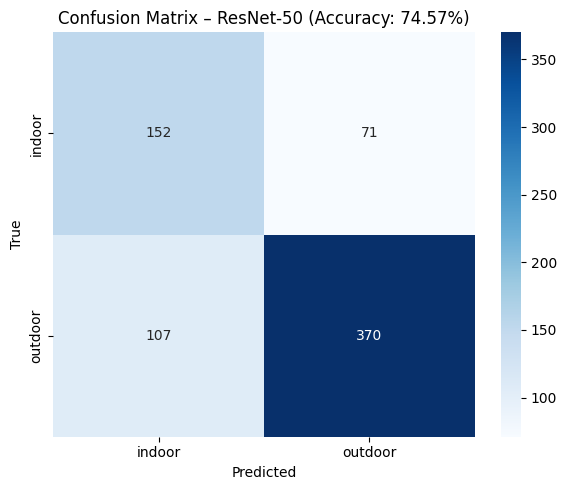

In [23]:
# ============================================================
# CELL 5: Confusion Matrix
# ============================================================
le = LabelEncoder()
le.classes_ = np.array(sorted(categories))
cm = confusion_matrix(le.transform(y_true), le.transform(y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – ResNet-50 (Accuracy: {accuracy:.2%})")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Data_Flickr/resnet_eval_confusion_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# CELL 6: Metrics + CSV speichern
# ============================================================
output_dir = "/content/drive/MyDrive/Data_Flickr"

# Metrics CSV
report = classification_report(y_true, y_pred,
                                target_names=sorted(categories),
                                output_dict=True)
pd.DataFrame(report).transpose().to_csv(
    os.path.join(output_dir, "resnet_metrics_700.csv"))

# Results CSV
pd.DataFrame({
    'file_name':  fnames,
    'true_label': y_true,
    'pred_label': y_pred,
    'confidence': confidences
}).to_csv(os.path.join(output_dir, "resnet_results_700.csv"), index=False)

print("✅ Gespeichert:")
print(f"   {output_dir}/resnet_metrics_700.csv")
print(f"   {output_dir}/resnet_results_700.csv")

✅ Gespeichert:
   /content/drive/MyDrive/Data_Flickr/resnet_metrics_700.csv
   /content/drive/MyDrive/Data_Flickr/resnet_results_700.csv
